# Stack Overflow Survey Compensation Model

This notebook takes the cleaned respondent parquet and does the final compensation modeling pass. The point is to compare a sensible range of models, keep the logic visible in the notebook, and end with one compensation benchmark that can then be mirrored in `src/compensation_modeling.py`.


In [1]:
import re
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import shap
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

# Ignore noisy packages
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Set display parameters to view more and keep easy to view style
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## Notebook Setup

1. Load `clean_core.parquet` and surface any extra fields needed for compensation modeling
2. Check geography coverage and compensation trends in the modeling sample
3. Lock the main window and the narrower side windows
4. Compare the geography baseline, Ridge, and LightGBM variants on the same year-aware split
5. Inspect the selected model and explore potential experimental branches

## Load Finalized Clean Core

The cleaned parquet stays lean, so this cell surfaces the notebook-only role flags, multiselect counts, and log compensation target that the model comparison needs.

In [2]:
CLEAN_PATH = ROOT / 'data' / 'derived' / 'clean_core.parquet'
clean_core = pd.read_parquet(CLEAN_PATH).copy()

ROLE_FAMILY_LEVELS = [
    'Advocacy / DX',
    'Architecture',
    'Back-end',
    'Data / ML',
    'Design / UX',
    'Desktop / Enterprise',
    'DevOps / Cloud',
    'Embedded / hardware',
    'Front-end',
    'Full-stack',
    'Game / graphics',
    'Management',
    'Mobile',
    'Other',
    'QA / Testing',
    'Security',
    'Student / Academic'
]
ROLE_FAMILY_COLS = {
    level: 'role_' + re.sub(r'[^a-z0-9]+', '_', level.lower()).strip('_')
    for level in ROLE_FAMILY_LEVELS
}


# Helper function to count the number of valid selections in a multi-select column
def multi_count(series):
    counts = (
        series.fillna('')
        .astype(str)
        .str.split(';')
        .map(lambda items: sum(item.strip() not in {'', 'nan'} for item in items))
    )
    return counts.where(series.notna(), np.nan)


# Helper function to map a role token to a role family
def role_family(token):
    if pd.isna(token):
        return pd.NA
    text = str(token).strip().lower()
    if 'architect' in text:
        return 'Architecture'
    if 'developer advocate' in text or 'developer experience' in text or 'devrel' in text:
        return 'Advocacy / DX'
    if 'designer' in text or 'ux' in text or 'ui' in text:
        return 'Design / UX'
    if 'embedded' in text or 'firmware' in text or 'hardware' in text:
        return 'Embedded / hardware'
    if 'game' in text or 'graphics' in text:
        return 'Game / graphics'
    if 'full-stack' in text:
        return 'Full-stack'
    if 'back-end' in text or 'backend' in text or 'server' in text:
        return 'Back-end'
    if 'front-end' in text or 'frontend' in text:
        return 'Front-end'
    if 'web developer' in text:
        return 'Full-stack'
    if 'data' in text or 'machine learning' in text or 'scientist' in text or 'analyst' in text or 'ai/ml' in text:
        return 'Data / ML'
    if 'mobile' in text or 'ios' in text or 'android' in text:
        return 'Mobile'
    if any(term in text for term in ['devops', 'site reliability', 'cloud', 'system administrator', 'systems administrator', 'sysadmin']):
        return 'DevOps / Cloud'
    if 'desktop' in text or 'enterprise' in text:
        return 'Desktop / Enterprise'
    if 'security' in text:
        return 'Security'
    if 'manager' in text or 'executive' in text:
        return 'Management'
    if 'student' in text or 'academic researcher' in text or 'educator' in text:
        return 'Student / Academic'
    if 'qa' in text or 'quality assurance' in text or 'test' in text:
        return 'QA / Testing'
    return 'Other'


# Helper function to build the role family value for a given multi-select role column value
def build_role_family_value(value):
    if pd.isna(value):
        return pd.NA

    tokens = []
    seen = set()
    for token in str(value).split(';'):
        token = token.strip()
        if not token:
            continue
        family = role_family(token)
        if pd.isna(family) or family in seen:
            continue
        seen.add(family)
        tokens.append(family)

    return ';'.join(tokens) if tokens else pd.NA


model_frame = clean_core.copy()
# Build role family column if not present
if 'role_family' not in model_frame.columns:
    model_frame['role_family'] = pd.NA
if model_frame['role_family'].isna().all() and 'dev_type' in model_frame.columns:
    model_frame['role_family'] = model_frame['dev_type'].map(build_role_family_value)

# Create count features for multi-select columns
count_map = {
    'language': 'language_count',
    'database': 'database_count',
    'platform': 'platform_count',
    'webframe': 'webframe_count',
    'misc_tech': 'misc_tech_count',
    'learn_code': 'learn_code_count',
    'learn_code_online': 'learn_code_online_count',
    'coding_activities': 'coding_activities_count',
    'op_sys_prof': 'op_sys_prof_count'
}
for source_col, count_col in count_map.items():
    if source_col in model_frame.columns:
        model_frame[count_col] = multi_count(model_frame[source_col])

# Create binary columns for role family membership
role_family_text = (
    ';'
    + model_frame['role_family']
    .fillna('')
    .astype(str)
    .str.replace(r'\s*;\s*', ';', regex=True)
    .str.strip('; ')
    + ';'
)
for level, col in ROLE_FAMILY_COLS.items():
    model_frame[col] = role_family_text.str.contains(f';{level};', regex=False, na=False).astype(int)

# Create log inflation adjusted compensation for main target variable
comp_real = pd.to_numeric(model_frame['comp_real_2025'], errors='coerce')
model_frame['log_comp_real_2025'] = np.where(comp_real.notna(), np.log(comp_real), np.nan)
model_frame['survey_year_str'] = model_frame['survey_year'].astype('Int64').astype(str)

# Make sure all numeric columns are of proper dtype
role_cols = sorted(col for col in model_frame.columns if col.startswith('role_') and col != 'role_family')
numeric_cols = [
    'survey_year',
    'age_mid',
    'professional_experience_years',
    'language_count',
    'database_count',
    'platform_count',
    'learn_code_count',
    'webframe_count',
    'misc_tech_count',
    'learn_code_online_count',
    'coding_activities_count',
    'op_sys_prof_count',
    'comp_usd_clean',
    'comp_real_2025',
    'log_comp_real_2025'
] + role_cols
for col in numeric_cols:
    if col in model_frame.columns:
        model_frame[col] = pd.to_numeric(model_frame[col], errors='coerce')

# Main analysis choice is respondents that are paid professional with compensation data
comp_analysis_mask = (
    model_frame['is_professional'].fillna(False).astype(bool)
    & model_frame['comp_usd_clean'].notna()
    & model_frame['is_paid_worker'].fillna(False).astype(bool)
)

# Modeling frame is restricted to 2019+ because of reliability of data
comp_model_mask = comp_analysis_mask & model_frame['survey_year'].ge(2019)

base_model_df = model_frame.loc[
    comp_model_mask
    & model_frame['country_clean'].notna()
    & model_frame['region'].notna()
].copy()

# Define subsets for different model windows
core_df = base_model_df.copy()
tech_df = base_model_df.loc[base_model_df['survey_year'].ge(2021)].copy()
ai_df = base_model_df.loc[base_model_df['survey_year'].ge(2023)].copy()
role_cols = sorted(col for col in base_model_df.columns if col.startswith('role_') and col != 'role_family')

print("clean_core shape:", clean_core.shape)
print("model_frame shape:", model_frame.shape)
display(base_model_df[['survey_year', 'country_clean', 'region', 'comp_real_2025']].sample(5))

clean_core shape: (746226, 64)
model_frame shape: (746226, 89)


,survey_year,country_clean,region,comp_real_2025
312769,2019,United Kingdom,Europe,74147.493646
605383,2023,Bangladesh,Asia,6895.261659
590226,2023,India,Asia,12802.618069
738855,2025,Sweden,Europe,73375.000000
359925,2020,Brazil,Americas,41034.792509


## Loaded Data QA

Checks missing cleaned countries and regions in the compensation sample, then shows the compensation trend before and after the inflation adjustment.


,window,rows,missing_country_clean,missing_region
0,2019+ core,240269,123,123
1,2021+ tech,160537,58,58
2,2023+ AI,84663,27,27


Countries still missing country_clean inside the compensation analysis sample


country
Other Country (Not Listed Above)    85
Nomadic                             70
Other (please specify)              13
I prefer not to say                  6
Name: count, dtype: int64[pyarrow]

,survey_year,comp_usd_clean,comp_real_2025
0,2019,56555.0,71218.42
1,2020,54000.0,67172.27
2,2021,55224.0,65612.36
3,2022,66540.0,73199.12
4,2023,75411.0,79677.99
5,2024,67666.0,69446.47
6,2025,80254.0,80254.00


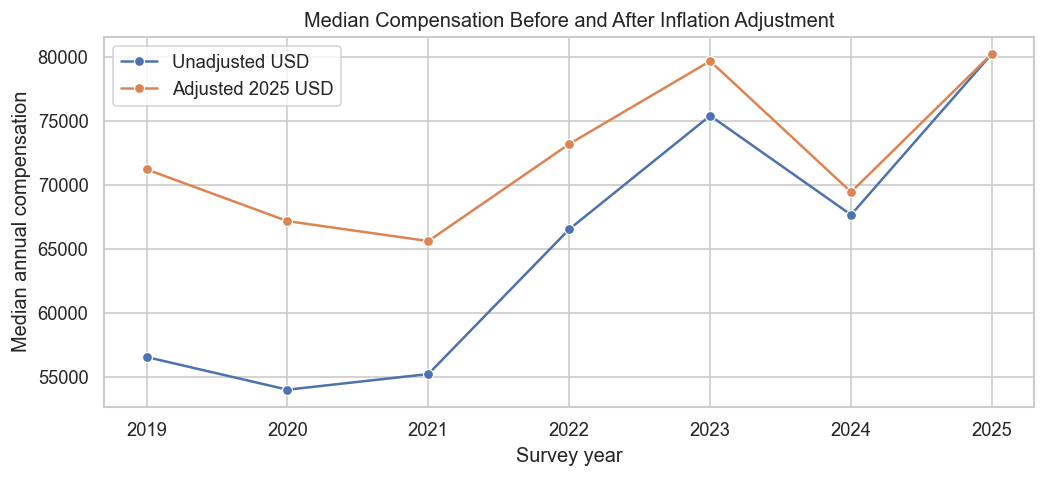

In [3]:
# Builds DataFrame defining windows we intend to use and the missing countries and regions in each
window_qa = pd.DataFrame([
    {
        'window': '2019+ core',
        'rows': int(comp_model_mask.sum()),
        'missing_country_clean': int(model_frame.loc[comp_model_mask, 'country_clean'].isna().sum()),
        'missing_region': int(model_frame.loc[comp_model_mask, 'region'].isna().sum())
    },
    {
        'window': '2021+ tech',
        'rows': int((comp_analysis_mask & model_frame['survey_year'].ge(2021)).sum()),
        'missing_country_clean': int(model_frame.loc[comp_analysis_mask & model_frame['survey_year'].ge(2021), 'country_clean'].isna().sum()),
        'missing_region': int(model_frame.loc[comp_analysis_mask & model_frame['survey_year'].ge(2021), 'region'].isna().sum())
    },
    {
        'window': '2023+ AI',
        'rows': int((comp_analysis_mask & model_frame['survey_year'].ge(2023)).sum()),
        'missing_country_clean': int(model_frame.loc[comp_analysis_mask & model_frame['survey_year'].ge(2023), 'country_clean'].isna().sum()),
        'missing_region': int(model_frame.loc[comp_analysis_mask & model_frame['survey_year'].ge(2023), 'region'].isna().sum())
    }
])
display(window_qa)

print("Countries still missing country_clean inside the compensation analysis sample")
display(
    clean_core.loc[
        comp_analysis_mask & clean_core['country_clean'].isna(),
        'country'
    ].value_counts().head(15)
)

# Median compensation per year, before and after inflation adjustment
median_comp = (
    model_frame.loc[comp_model_mask]
    .groupby('survey_year')[['comp_usd_clean', 'comp_real_2025']]
    .median()
    .reset_index()
)
display(median_comp.round(2))

# Trendlines for compensation
plt.figure(figsize=(10, 4))
sns.lineplot(data=median_comp, x='survey_year', y='comp_usd_clean', marker='o', label='Unadjusted USD')
sns.lineplot(data=median_comp, x='survey_year', y='comp_real_2025', marker='o', label='Adjusted 2025 USD')
plt.title('Median Compensation Before and After Inflation Adjustment')
plt.xlabel('Survey year')
plt.ylabel('Median annual compensation')
plt.legend()
plt.show()

## Final Window Choice

The main model should use the widest window that still has solid feature coverage, so the core window stays at `2019+`. The later windows stay in as side analyses for the richer remote, tech, learning, and AI fields.


In [4]:
RANDOM_STATE = 42

# Define target variable names for modeling
COMP_TARGET = 'log_comp_real_2025'
COMP_REAL = 'comp_real_2025'
WINSOR_REAL = 'comp_real_2025_winsor'
WINSOR_TARGET = 'log_comp_real_2025_winsor'

# Define training windows and corresponding validation/test years for each set of features
CORE_WINDOW_YEARS = [2019, 2020, 2021, 2022, 2023]
TECH_WINDOW_YEARS = [2021, 2022, 2023]
AI_WINDOW_YEARS = [2023]
VALID_YEAR = 2024
TEST_YEAR = 2025

# Ridge regression alphas to test for baseline models and comparison to LightGBM performance
RIDGE_ALPHAS = [1.0, 5.0, 10.0, 25.0]
BASELINE_GROUP_SETS = [['country_clean'], ['region'], []]

# Define top N technologies to keep for each category based on overall popularity in the compensation sample
TOP_N_TECH = {
    'language': 15,
    'database': 10,
    'platform': 10
}

# Base LightGBM parameters for initial modeling
DEFAULT_LGB_PARAMS = {
    'objective': 'regression_l1',
    'metric': 'l1',
    'boosting_type': 'gbdt',
    'n_estimators': 300,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.0,
    'reg_lambda': 0.0,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1
}

# LightGBM parameters tuned with Optuna for best model performance
NOTEBOOK_TUNED_LGB_PARAMS = {
    'objective': 'regression_l1',
    'metric': 'l1',
    'boosting_type': 'gbdt',
    'n_estimators': 659,
    'learning_rate': 0.04280768609535672,
    'num_leaves': 104,
    'max_depth': 11,
    'min_child_samples': 22,
    'subsample': 0.6872084049537491,
    'colsample_bytree': 0.7368883480938272,
    'reg_alpha': 9.28733327190043,
    'reg_lambda': 3.8666260444964735e-07,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1
}
LGB_PRESETS = {
    'default': DEFAULT_LGB_PARAMS,
    'tuned': NOTEBOOK_TUNED_LGB_PARAMS
}

# Categorical and numeric features for the core window
CORE_CAT = [
    'survey_year_str',
    'region',
    'country_clean',
    'employment_primary',
    'education_clean',
    'org_size_clean'
]
CORE_NUM = [
    'age_mid',
    'professional_experience_years',
    'language_count',
    'database_count',
    'platform_count'
] + role_cols

# Categorical and numeric features for the tech window
TECH_CAT = CORE_CAT.copy()
TECH_NUM = CORE_NUM + [
    col for col in ['learn_code_count', 'webframe_count', 'misc_tech_count']
    if col in tech_df.columns
]

# Categorical and numeric features for the AI window
AI_CAT = CORE_CAT + [
    col for col in ['remote_group', 'ai_use', 'ai_sent']
    if col in ai_df.columns
]
AI_NUM = TECH_NUM + [
    col for col in ['learn_code_online_count', 'coding_activities_count', 'op_sys_prof_count']
    if col in ai_df.columns
]

window_summary = pd.DataFrame([
    {
        'window': '2019+ core',
        'rows': len(core_df),
        'train_years': '2019-2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(core_df['age_mid'].notna().mean(), 3),
        'experience_share': round(core_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(core_df['country_clean'].notna().mean(), 3),
        'remote_share': round(core_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(core_df['ai_sent'].notna().mean(), 3)
    },
    {
        'window': '2021+ tech',
        'rows': len(tech_df),
        'train_years': '2021-2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(tech_df['age_mid'].notna().mean(), 3),
        'experience_share': round(tech_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(tech_df['country_clean'].notna().mean(), 3),
        'remote_share': round(tech_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(tech_df['ai_sent'].notna().mean(), 3)
    },
    {
        'window': '2023+ AI',
        'rows': len(ai_df),
        'train_years': '2023',
        'valid_year': 2024,
        'test_year': 2025,
        'age_share': round(ai_df['age_mid'].notna().mean(), 3),
        'experience_share': round(ai_df['professional_experience_years'].notna().mean(), 3),
        'country_share': round(ai_df['country_clean'].notna().mean(), 3),
        'remote_share': round(ai_df['remote_group'].notna().mean(), 3),
        'ai_sent_share': round(ai_df['ai_sent'].notna().mean(), 3)
    }
])

display(window_summary)

,window,rows,train_years,valid_year,test_year,age_share,experience_share,country_share,remote_share,ai_sent_share
0,2019+ core,240146,2019-2023,2024,2025,0.975,0.991,1.0,0.681,0.273
1,2021+ tech,160479,2021-2023,2024,2025,0.997,0.992,1.0,0.728,0.408
2,2023+ AI,84636,2023,2024,2025,0.998,0.994,1.0,0.979,0.773


## Benchmark And Ridge Tuning

The first serious benchmark after the geography median is a tuned Ridge model on the same main window. This keeps an interpretable reference point in the notebook before moving into the nonlinear LightGBM branch.

In [7]:
# Reusable function to split any given DataFrame into train, valid, and test sets based on specified years
def split_years(frame, train_years, valid_year, test_year):
    train = frame.loc[frame['survey_year'].isin(train_years)].copy()
    valid = frame.loc[frame['survey_year'] == valid_year].copy()
    test = frame.loc[frame['survey_year'] == test_year].copy()
    return train, valid, test


# Reusable generator function to create rolling origin splits for any given DataFrame based on survey_year
def rolling_origin_splits(frame, min_train_year=2019, final_valid_year=2024):
    years = sorted(year for year in frame['survey_year'].dropna().unique() if year >= min_train_year)
    for valid_year in years:
        if valid_year > final_valid_year:
            continue
        train_years = [year for year in years if year < valid_year]
        if not train_years:
            continue
        train = frame.loc[frame['survey_year'].isin(train_years)].copy()
        valid = frame.loc[frame['survey_year'] == valid_year].copy()
        if len(train) and len(valid):
            yield train_years, valid_year, train, valid


# Reusable scoring function to do a full round of evaluation metrics
def score_predictions(y_true_log, pred_log):
    y_true_real = np.exp(np.asarray(y_true_log, dtype=float))
    pred_real = np.exp(np.asarray(pred_log, dtype=float))
    return {
        'medae_real': median_absolute_error(y_true_real, pred_real),
        'mae_real': mean_absolute_error(y_true_real, pred_real),
        'rmse_real': np.sqrt(mean_squared_error(y_true_real, pred_real)),
        'rmse_log': np.sqrt(mean_squared_error(y_true_log, pred_log)),
        'r2_log': r2_score(y_true_log, pred_log)
    }


# Baseline prediction function, fills missing predictions with hierarchical median of given group, then scores them
def predict_hier_median(train_df, score_df, group_sets, target_col=COMP_REAL):
    pred = pd.Series(np.nan, index=score_df.index, dtype='float64')

    for group_cols in group_sets:
        if not group_cols:
            pred = pred.fillna(train_df[target_col].median())
            continue

        medians = (
            train_df
            .groupby(group_cols, dropna=False)[target_col]
            .median()
            .rename('pred_real')
            .reset_index()
        )
        scored = score_df[group_cols].merge(medians, on=group_cols, how='left')
        pred = pred.fillna(pd.Series(scored['pred_real'].to_numpy(), index=score_df.index))

    pred = pred.fillna(train_df[target_col].median())
    return np.log(pred)


# Scores the baseline models on the holdout test set
def score_holdout_baseline(train_df, valid_df, test_df, group_sets=None):
    group_sets = BASELINE_GROUP_SETS if group_sets is None else group_sets
    valid_pred = predict_hier_median(train_df, valid_df, group_sets)
    valid_metrics = score_predictions(valid_df[COMP_TARGET], valid_pred)

    train_valid = pd.concat([train_df, valid_df], axis=0)
    test_pred = predict_hier_median(train_valid, test_df, group_sets)
    test_metrics = score_predictions(test_df[COMP_TARGET], test_pred)
    return {
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics
    }


# Helper function to create a result row for easy comparison of different models and windows
def result_row(name, result):
    return {
        'setup': name,
        'valid_medae_real': result['valid_metrics']['medae_real'],
        'test_medae_real': result['test_metrics']['medae_real'],
        'test_rmse_real': result['test_metrics']['rmse_real'],
        'test_r2_log': result['test_metrics']['r2_log']
    }


# Normalizes all columns of a given DataFrame to the appropriate types for categorical and numerical features
def normalize_feature_frame(frame, cat_cols, num_cols):
    out = frame.copy()
    for col in cat_cols:
        out[col] = out[col].astype(object)
        out.loc[out[col].isna(), col] = np.nan
    for col in num_cols:
        out[col] = pd.to_numeric(out[col], errors='coerce').astype(float)
    return out


# Sets up a full Pipeline for preprocessing and fitting the Ridge Regression model
def build_ridge_pipe(cat_cols, num_cols):
    prep = ColumnTransformer([
        (
            'cat', Pipeline([
                ('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
                ('encode', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=500))
            ]),
            cat_cols
        ),
        (
            'num', Pipeline([
                ('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler())
            ]),
            num_cols
        )
    ])
    return Pipeline([
        ('prep', prep),
        ('model', Ridge())
    ])


# Fits multiple Ridge models with different alpha values, evaluates on valid set to get best model, then fits the full model and evaluates on the holdout set
def fit_ridge_holdout(train_df, valid_df, test_df, cat_cols, num_cols, alphas=None):
    alphas = RIDGE_ALPHAS if alphas is None else alphas
    feature_cols = cat_cols + num_cols
    train_df = normalize_feature_frame(train_df, cat_cols, num_cols)
    valid_df = normalize_feature_frame(valid_df, cat_cols, num_cols)
    test_df = normalize_feature_frame(test_df, cat_cols, num_cols)

    pipe = build_ridge_pipe(cat_cols, num_cols)
    trials = []
    best_alpha = None
    best_valid = None

    for alpha in alphas:
        model = clone(pipe)
        model.set_params(model=Ridge(alpha=alpha))
        model.fit(train_df[feature_cols], train_df[COMP_TARGET])
        valid_metrics = score_predictions(valid_df[COMP_TARGET], model.predict(valid_df[feature_cols]))
        trials.append({
            'alpha': alpha,
            **{f'valid_{key}': value for key, value in valid_metrics.items()}
        })
        if best_valid is None or valid_metrics['medae_real'] < best_valid['medae_real']:
            best_valid = valid_metrics
            best_alpha = alpha

    final_model = clone(pipe)
    final_model.set_params(model=Ridge(alpha=best_alpha))
    train_valid = pd.concat([train_df, valid_df], axis=0)
    final_model.fit(train_valid[feature_cols], train_valid[COMP_TARGET])
    test_metrics = score_predictions(test_df[COMP_TARGET], final_model.predict(test_df[feature_cols]))

    return {
        'trials': pd.DataFrame(trials),
        'best_params': {'alpha': best_alpha},
        'model': final_model,
        'feature_cols': feature_cols,
        'valid_metrics': best_valid,
        'test_metrics': test_metrics
    }


# Fit the main-window geography baseline and Ridge benchmark before moving to LightGBM
core_train, core_valid, core_test = split_years(core_df, CORE_WINDOW_YEARS, VALID_YEAR, TEST_YEAR)

baseline_result = score_holdout_baseline(core_train, core_valid, core_test)
ridge_result = fit_ridge_holdout(core_train, core_valid, core_test, CORE_CAT, CORE_NUM)

print("Ridge alpha trials")
display(ridge_result['trials'].round(2))

early_benchmark = pd.DataFrame([
    result_row('Country-region median baseline', baseline_result),
    result_row('Ridge core', ridge_result)
]).sort_values('valid_medae_real')

display(early_benchmark.round(2))

Ridge alpha trials


,alpha,valid_medae_real,valid_mae_real,valid_rmse_real,valid_rmse_log,valid_r2_log
0,1.0,19926.98,34324.88,62211.82,0.74,0.52
1,5.0,19915.16,34319.91,62210.84,0.74,0.52
2,10.0,19891.53,34314.37,62210.16,0.74,0.52
3,25.0,19856.74,34299.89,62209.06,0.74,0.52


,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
1,Ridge core,19856.74,23462.86,72296.30,0.48
0,Country-region median baseline,21836.51,23555.65,72858.83,0.43


## Core LightGBM Comparison

Builds potential benchark LightGBM models with the following:
- plain core LightGBM on the comparable main window
- top-tech flags learned from the training rows only
- winsorized-target sensitivity using training-fit country thresholds
- comparison between the conservative default preset and the stronger preset from the Colab tuning pass

In [8]:
# Gets the top N most common tech fields from a given column, handles multiple semicolon-separated values
def extract_top_techs(frame, column, n):
    tokens = (
        frame[column]
        .dropna()
        .astype(str)
        .str.split(';')
        .explode()
        .str.strip()
    )
    tokens = tokens.loc[tokens.ne('')]
    return tokens.value_counts().head(n).index.tolist()


# Replaces special characters in tech names with safe alternatives, for flagging
def tech_flag_name(column, tech):
    safe = (
        tech.lower()
        .replace('++', '_plusplus_')
        .replace('+', '_plus_')
        .replace('#', '_sharp_')
        .replace('.', '_dot_')
        .replace('/', '_slash_')
        .replace('&', '_and_')
        .replace(' ', '_')
    )
    safe = ''.join(ch if ch.isalnum() or ch == '_' else '_' for ch in safe)
    safe = '_'.join(part for part in safe.split('_') if part)
    return f'{column}_{safe}'


# Adds binary flag columns for whether each of the top N technologies in each category is mentioned
def add_top_tech_flags(frame, top_n_map=None, fit_frame=None):
    top_n_map = TOP_N_TECH if top_n_map is None else top_n_map
    fit_source = frame if fit_frame is None else fit_frame
    out = frame.copy()
    created = []

    for column, n in top_n_map.items():
        if column not in out.columns or column not in fit_source.columns:
            continue

        normalized = (
            ';'
            + out[column]
            .fillna('')
            .astype(str)
            .str.replace(r'\s*;\s*', ';', regex=True)
            .str.strip('; ')
            + ';'
        )

        for tech in extract_top_techs(fit_source, column, n):
            col_name = tech_flag_name(column, tech)
            out[col_name] = normalized.str.contains(f';{tech};', regex=False, na=False).astype(int)
            created.append(col_name)

    return out, created


# Adds winsorized versions of the compensation target based on group-specific thresholds
def add_winsor_targets(frame, fit_frame=None, group_cols=('country_clean',), lower_q=0.01, upper_q=0.99, min_group_size=20):
    out = frame.copy()
    out[COMP_REAL] = pd.to_numeric(out[COMP_REAL], errors='coerce')

    fit_source = out if fit_frame is None else fit_frame.copy()
    fit_source[COMP_REAL] = pd.to_numeric(fit_source[COMP_REAL], errors='coerce')

    if group_cols:
        thresholds = (
            fit_source
            .groupby(list(group_cols), dropna=False)[COMP_REAL]
            .agg(
                group_size='size',
                lower=lambda series: series.quantile(lower_q),
                upper=lambda series: series.quantile(upper_q)
            )
            .reset_index()
        )
        thresholds.loc[thresholds['group_size'] < min_group_size, ['lower', 'upper']] = np.nan
        out = out.merge(thresholds[list(group_cols) + ['lower', 'upper']], on=list(group_cols), how='left')
    else:
        out['lower'] = np.nan
        out['upper'] = np.nan

    global_lower = fit_source[COMP_REAL].quantile(lower_q)
    global_upper = fit_source[COMP_REAL].quantile(upper_q)
    out['lower'] = out['lower'].fillna(global_lower)
    out['upper'] = out['upper'].fillna(global_upper)
    out[WINSOR_REAL] = out[COMP_REAL].clip(lower=out['lower'], upper=out['upper'])
    out[WINSOR_TARGET] = np.log(out[WINSOR_REAL])
    return out.drop(columns=['lower', 'upper'])


# Prepares a DataFrame for LightGBM by normalizing types, imputing numericals, and encoding categoricals as categories
def prepare_lgbm_frame(frame, cat_cols, num_cols, target_col=COMP_TARGET):
    out = frame.copy()

    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing').astype('category')

    num_imputer = SimpleImputer(strategy='median')
    out_num = pd.DataFrame(
        num_imputer.fit_transform(out[num_cols]),
        columns=num_cols,
        index=out.index
    )
    out[num_cols] = out_num

    if target_col in out.columns:
        out[target_col] = pd.to_numeric(out[target_col], errors='coerce')

    return out, num_imputer


# Transforms LightGBM model input frame based on the imputer fitted on the training data
def transform_lgbm_frame(frame, cat_cols, num_cols, num_imputer, target_col=COMP_TARGET):
    out = frame.copy()

    for col in cat_cols:
        out[col] = out[col].astype('string').fillna('Missing').astype('category')

    out_num = pd.DataFrame(
        num_imputer.transform(out[num_cols]),
        columns=num_cols,
        index=out.index
    )
    out[num_cols] = out_num

    if target_col in out.columns:
        out[target_col] = pd.to_numeric(out[target_col], errors='coerce')

    return out


# Fits a LightGBM model on the training set with early stopping based on the validation set, then fits a final model on the combined train and valid sets and evaluates on the holdout test set
def fit_lightgbm_holdout(train_df, valid_df, test_df, cat_cols, num_cols, target_col=COMP_TARGET, params=None, score_target_col=None, early_stopping_rounds=50):
    score_target_col = target_col if score_target_col is None else score_target_col
    resolved_params = dict(DEFAULT_LGB_PARAMS if params is None else params)
    features = cat_cols + num_cols

    train_prepped, num_imputer = prepare_lgbm_frame(train_df, cat_cols, num_cols, target_col)
    valid_prepped = transform_lgbm_frame(valid_df, cat_cols, num_cols, num_imputer, target_col)

    early_model = lgb.LGBMRegressor(**resolved_params)
    early_model.fit(
        train_prepped[features],
        train_prepped[target_col].to_numpy(),
        eval_set=[(valid_prepped[features], valid_prepped[target_col].to_numpy())],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)]
    )
    best_iteration = early_model.best_iteration_ or resolved_params.get('n_estimators', DEFAULT_LGB_PARAMS['n_estimators'])
    valid_pred = early_model.predict(valid_prepped[features], num_iteration=best_iteration)
    valid_metrics = score_predictions(valid_df[score_target_col], valid_pred)

    final_params = dict(resolved_params)
    final_params['n_estimators'] = best_iteration
    final_model = lgb.LGBMRegressor(**final_params)
    train_valid_raw = pd.concat([train_df, valid_df], axis=0)
    final_train, full_num_imputer = prepare_lgbm_frame(train_valid_raw, cat_cols, num_cols, target_col)
    final_test = transform_lgbm_frame(test_df, cat_cols, num_cols, full_num_imputer, target_col)
    final_model.fit(final_train[features], final_train[target_col].to_numpy())
    test_pred = final_model.predict(final_test[features])
    test_metrics = score_predictions(test_df[score_target_col], test_pred)

    return {
        'model': final_model,
        'best_params': final_params,
        'feature_cols': features,
        'plot_frame': final_test,
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics,
        'valid_pred': valid_pred,
        'test_pred': test_pred,
        'test_df': test_df.copy()
    }


# Similar to fit_lightgbm_holgout but adds target variable winsorization
def fit_lightgbm_winsor_holdout(train_df, valid_df, test_df, cat_cols, num_cols, params=None, group_cols=('country_clean',), early_stopping_rounds=50):
    resolved_params = dict(DEFAULT_LGB_PARAMS if params is None else params)
    train_winsor = add_winsor_targets(train_df, fit_frame=train_df, group_cols=group_cols)
    valid_winsor = add_winsor_targets(valid_df, fit_frame=train_df, group_cols=group_cols)
    features = cat_cols + num_cols

    train_prepped, num_imputer = prepare_lgbm_frame(train_winsor, cat_cols, num_cols, WINSOR_TARGET)
    valid_prepped = transform_lgbm_frame(valid_winsor, cat_cols, num_cols, num_imputer, WINSOR_TARGET)

    early_model = lgb.LGBMRegressor(**resolved_params)
    early_model.fit(
        train_prepped[features],
        train_prepped[WINSOR_TARGET].to_numpy(),
        eval_set=[(valid_prepped[features], valid_prepped[WINSOR_TARGET].to_numpy())],
        callbacks=[lgb.early_stopping(early_stopping_rounds, verbose=False)]
    )
    best_iteration = early_model.best_iteration_ or resolved_params.get('n_estimators', DEFAULT_LGB_PARAMS['n_estimators'])
    valid_pred = early_model.predict(valid_prepped[features], num_iteration=best_iteration)
    valid_metrics = score_predictions(valid_winsor[COMP_TARGET], valid_pred)

    full_train_raw = pd.concat([train_df, valid_df], axis=0)
    full_train_winsor = add_winsor_targets(full_train_raw, fit_frame=full_train_raw, group_cols=group_cols)
    full_test_winsor = add_winsor_targets(test_df, fit_frame=full_train_raw, group_cols=group_cols)
    final_params = dict(resolved_params)
    final_params['n_estimators'] = best_iteration
    final_model = lgb.LGBMRegressor(**final_params)
    final_train, full_num_imputer = prepare_lgbm_frame(full_train_winsor, cat_cols, num_cols, WINSOR_TARGET)
    final_test = transform_lgbm_frame(full_test_winsor, cat_cols, num_cols, full_num_imputer, WINSOR_TARGET)
    final_model.fit(final_train[features], final_train[WINSOR_TARGET].to_numpy())
    test_pred = final_model.predict(final_test[features])
    test_metrics = score_predictions(full_test_winsor[COMP_TARGET], test_pred)

    return {
        'model': final_model,
        'best_params': final_params,
        'feature_cols': features,
        'plot_frame': final_test,
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics,
        'valid_pred': valid_pred,
        'test_pred': test_pred,
        'test_df': test_df.copy()
    }


# Main function to fit a LightGBM model on a given window with options for top tech flags and winsorization
def fit_window_lightgbm(window_df, train_years, valid_year, test_year, cat_cols, num_cols, params=None, use_top_tech=True, winsor_target=False):
    train_df, valid_df, test_df = split_years(window_df, train_years, valid_year, test_year)
    tech_flag_cols = []

    if use_top_tech:
        train_df, tech_flag_cols = add_top_tech_flags(train_df, fit_frame=train_df)
        valid_df, _ = add_top_tech_flags(valid_df, fit_frame=train_df)
        test_df, _ = add_top_tech_flags(test_df, fit_frame=train_df)

    final_num_cols = num_cols + tech_flag_cols
    if winsor_target:
        result = fit_lightgbm_winsor_holdout(train_df, valid_df, test_df, cat_cols, final_num_cols, params=params)
    else:
        result = fit_lightgbm_holdout(train_df, valid_df, test_df, cat_cols, final_num_cols, params=params)

    return {
        'train_df': train_df,
        'valid_df': valid_df,
        'test_df': test_df,
        'tech_flag_cols': tech_flag_cols,
        'cat_cols': cat_cols,
        'num_cols': final_num_cols,
        **result
    }


# Helper function to plot SHAP summary plot for a given model result
def plot_shap_summary(result, title, sample_size=2000, max_display=20):
    plot_frame = result['plot_frame']
    if plot_frame.empty:
        print('No rows available for SHAP')
        return

    sample_n = min(sample_size, len(plot_frame))
    shap_frame = plot_frame.sample(sample_n, random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(result['model'])
    shap_values = explainer(shap_frame[result['feature_cols']])
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, shap_frame[result['feature_cols']], max_display=max_display, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [9]:
lightgbm_results = []
lightgbm_models = {}

# Fit LightGBM models on three different setups for each parameter preset
for preset_name, preset_params in LGB_PRESETS.items():
    core_plain = fit_window_lightgbm(
        core_df,
        CORE_WINDOW_YEARS,
        VALID_YEAR,
        TEST_YEAR,
        CORE_CAT,
        CORE_NUM,
        params=preset_params,
        use_top_tech=False,
        winsor_target=False
    )
    core_top_tech = fit_window_lightgbm(
        core_df,
        CORE_WINDOW_YEARS,
        VALID_YEAR,
        TEST_YEAR,
        CORE_CAT,
        CORE_NUM,
        params=preset_params,
        use_top_tech=True,
        winsor_target=False
    )
    core_winsor_top_tech = fit_window_lightgbm(
        core_df,
        CORE_WINDOW_YEARS,
        VALID_YEAR,
        TEST_YEAR,
        CORE_CAT,
        CORE_NUM,
        params=preset_params,
        use_top_tech=True,
        winsor_target=True
    )

    lightgbm_models[(preset_name, 'core')] = core_plain
    lightgbm_models[(preset_name, 'core_top_tech')] = core_top_tech
    lightgbm_models[(preset_name, 'core_winsor_top_tech')] = core_winsor_top_tech

    lightgbm_results.extend([
        result_row(f'LightGBM core [{preset_name}]', core_plain),
        result_row(f'LightGBM core + top tech flags [{preset_name}]', core_top_tech),
        result_row(f'LightGBM winsorized target + top tech flags [{preset_name}]', core_winsor_top_tech)
    ])

# Compile all core model results into a single DataFrame for comparison
core_comparison = pd.DataFrame([
    result_row('Country-region median baseline', baseline_result),
    result_row('Ridge core', ridge_result),
    *lightgbm_results
]).sort_values('valid_medae_real')

display(core_comparison.round(2))

,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
7,LightGBM winsorized target + top tech flags [t...,14764.28,17831.00,62955.15,0.57
6,LightGBM core + top tech flags [tuned],14894.98,17774.45,62970.94,0.57
4,LightGBM winsorized target + top tech flags [d...,14965.52,17960.17,63075.82,0.56
3,LightGBM core + top tech flags [default],15012.40,17991.34,63140.65,0.56
5,LightGBM core [tuned],15195.10,18661.39,65227.39,0.55
2,LightGBM core [default],15330.76,18733.49,65210.32,0.55
1,Ridge core,19856.74,23462.86,72296.30,0.48
0,Country-region median baseline,21836.51,23555.65,72858.83,0.43


## Later-Year Side Window Comparison

The later windows stay as side analyses rather than replacements for the main model window.

In [10]:
# Base LightGBM model for the tech window
tech_plain = fit_window_lightgbm(
    tech_df,
    TECH_WINDOW_YEARS,
    VALID_YEAR,
    TEST_YEAR,
    TECH_CAT,
    TECH_NUM,
    params=NOTEBOOK_TUNED_LGB_PARAMS,
    use_top_tech=True,
    winsor_target=False
)

# Winsorized target LightGBM model for the tech window
tech_winsor = fit_window_lightgbm(
    tech_df,
    TECH_WINDOW_YEARS,
    VALID_YEAR,
    TEST_YEAR,
    TECH_CAT,
    TECH_NUM,
    params=NOTEBOOK_TUNED_LGB_PARAMS,
    use_top_tech=True,
    winsor_target=True
)

# Base LightGBM model for the AI window
ai_plain = fit_window_lightgbm(
    ai_df,
    AI_WINDOW_YEARS,
    VALID_YEAR,
    TEST_YEAR,
    AI_CAT,
    AI_NUM,
    params=NOTEBOOK_TUNED_LGB_PARAMS,
    use_top_tech=True,
    winsor_target=False
)

# Winsorized target LightGBM model for the AI window
ai_winsor = fit_window_lightgbm(
    ai_df,
    AI_WINDOW_YEARS,
    VALID_YEAR,
    TEST_YEAR,
    AI_CAT,
    AI_NUM,
    params=NOTEBOOK_TUNED_LGB_PARAMS,
    use_top_tech=True,
    winsor_target=True
)

side_window_results = pd.DataFrame([
    result_row('Tech window LightGBM + top tech flags', tech_plain),
    result_row('Tech window LightGBM winsorized + top tech flags', tech_winsor),
    result_row('AI window LightGBM + top tech flags', ai_plain),
    result_row('AI window LightGBM winsorized + top tech flags', ai_winsor)
]).sort_values('valid_medae_real')

display(side_window_results.round(2))

,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
3,AI window LightGBM winsorized + top tech flags,14729.22,17372.05,63240.27,0.58
2,AI window LightGBM + top tech flags,14734.54,17419.99,63282.93,0.58
1,Tech window LightGBM winsorized + top tech flags,15075.02,17888.54,63008.73,0.57
0,Tech window LightGBM + top tech flags,15254.82,17759.27,63003.91,0.57


## SHAP Summary For The Main Model

The selected main model stays the tuned LightGBM with the winsorized target and top-tech flags.

,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
0,LightGBM winsorized target + top tech flags [t...,14764.28,17831.0,62955.15,0.57


Selected LightGBM parameters


,objective,metric,boosting_type,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,random_state,n_jobs,verbosity
0,regression_l1,l1,gbdt,659,0.042808,104,11,22,0.687208,0.736888,9.287333,3.866626e-07,42,-1,-1


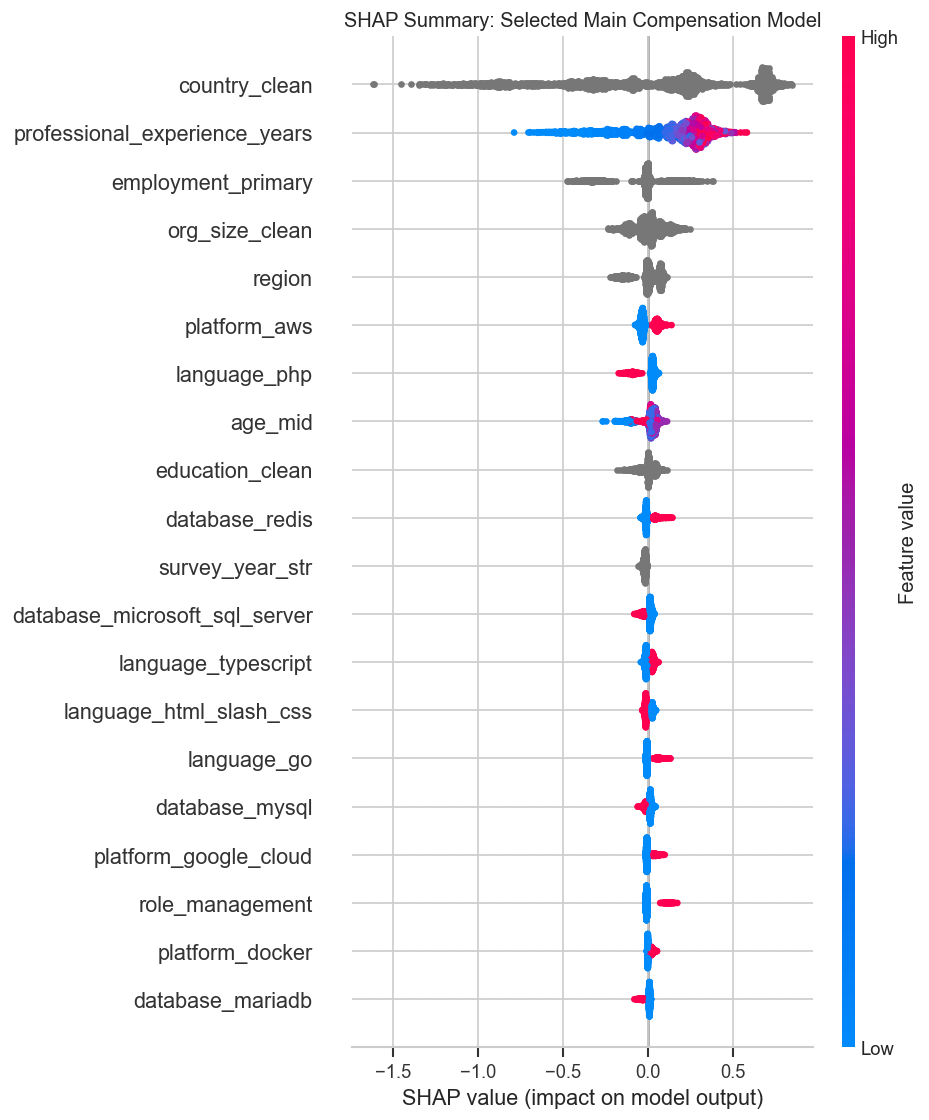

In [11]:
# Select the best performing model and display its metrics
selected_main = lightgbm_models[('tuned', 'core_winsor_top_tech')]
selected_main_metrics = pd.DataFrame([
    result_row('LightGBM winsorized target + top tech flags [tuned]', selected_main)
])
display(selected_main_metrics.round(2))

# Display the selected LightGBM parameters
print("Selected LightGBM parameters")
display(pd.DataFrame([selected_main['best_params']]))

plot_shap_summary(
    selected_main,
    'SHAP Summary: Selected Main Compensation Model',
    sample_size=2000,
    max_display=20
)

## Two-Stage Geography Backbone Plus Residuals Model

This branch keeps uses a geography backbone as a first model stage, then tests whether a second-stage LightGBM on the residuals meaningfully improves the model.

In [12]:
# Creates a basic geographic prediction function based on medians by country and region, first stage of residual modeling
def build_geo_backbone(train_df):
    country_median = train_df.groupby('country_clean')[COMP_REAL].median().rename('pred_country').reset_index()
    region_median = train_df.groupby('region')[COMP_REAL].median().rename('pred_region').reset_index()
    overall = train_df[COMP_REAL].median()

    def predict(frame):
        out = frame[['country_clean', 'region']].copy()
        out = out.merge(country_median, on='country_clean', how='left')
        out = out.merge(region_median, on='region', how='left')
        pred_real = out['pred_country'].fillna(out['pred_region']).fillna(overall)
        return pd.Series(np.log(pred_real.to_numpy()), index=frame.index)

    return predict


# Main function to fit a two-stage LightGBM model where the first stage is a geographic backbone and the second stage models residuals with additional features
def fit_two_stage_lightgbm(train_df, valid_df, test_df, params=None):
    residual_cat = [col for col in CORE_CAT if col not in ['country_clean', 'region']]

    train_with_flags, tech_flag_cols = add_top_tech_flags(train_df, fit_frame=train_df)
    valid_with_flags, _ = add_top_tech_flags(valid_df, fit_frame=train_df)
    residual_num = CORE_NUM + tech_flag_cols

    valid_backbone = build_geo_backbone(train_df)
    train_base_log = valid_backbone(train_df)
    valid_base_log = valid_backbone(valid_df)
    train_with_flags['target_resid'] = train_with_flags[COMP_TARGET] - train_base_log
    valid_with_flags['target_resid'] = valid_with_flags[COMP_TARGET] - valid_base_log

    residual_model = fit_lightgbm_holdout(
        train_with_flags,
        valid_with_flags,
        valid_with_flags,
        residual_cat,
        residual_num,
        target_col='target_resid',
        score_target_col='target_resid',
        params=params
    )
    valid_pred = valid_base_log + residual_model['valid_pred']
    valid_metrics = score_predictions(valid_df[COMP_TARGET], valid_pred)

    train_valid = pd.concat([train_df, valid_df], axis=0)
    train_valid_with_flags, final_tech_flag_cols = add_top_tech_flags(train_valid, fit_frame=train_valid)
    test_with_flags, _ = add_top_tech_flags(test_df, fit_frame=train_valid)
    final_residual_num = CORE_NUM + final_tech_flag_cols

    test_backbone = build_geo_backbone(train_valid)
    train_valid_base_log = test_backbone(train_valid)
    test_base_log = test_backbone(test_df)
    train_valid_with_flags['target_resid'] = train_valid_with_flags[COMP_TARGET] - train_valid_base_log

    final_params = dict(residual_model['best_params'])
    final_features = residual_cat + final_residual_num
    final_train_prepped, final_num_imputer = prepare_lgbm_frame(train_valid_with_flags, residual_cat, final_residual_num, 'target_resid')
    final_test_prepped = transform_lgbm_frame(test_with_flags, residual_cat, final_residual_num, final_num_imputer, 'target_resid')
    final_model = lgb.LGBMRegressor(**final_params)
    final_model.fit(final_train_prepped[final_features], final_train_prepped['target_resid'].to_numpy())
    test_resid_pred = final_model.predict(final_test_prepped[final_features])
    test_pred = test_base_log + test_resid_pred
    test_metrics = score_predictions(test_df[COMP_TARGET], test_pred)

    return {
        'model': final_model,
        'feature_cols': final_features,
        'plot_frame': final_test_prepped,
        'valid_metrics': valid_metrics,
        'test_metrics': test_metrics
    }


# Test the lighter two-stage geography branch against the selected single-stage model
two_stage_result = fit_two_stage_lightgbm(
    core_train,
    core_valid,
    core_test,
    params=NOTEBOOK_TUNED_LGB_PARAMS
)

two_stage_summary = pd.DataFrame([
    result_row('Country-region median baseline', baseline_result),
    result_row('Selected single-stage LightGBM', selected_main),
    result_row('Two-stage LightGBM residual', two_stage_result)
]).sort_values('valid_medae_real')

display(two_stage_summary.round(2))

,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
1,Selected single-stage LightGBM,14764.28,17831.00,62955.15,0.57
2,Two-stage LightGBM residual,16051.35,19020.54,64196.24,0.55
0,Country-region median baseline,21836.51,23555.65,72858.83,0.43


## GDP PPP Corrected LightGBM Model

This is a side check on whether broad country-level cost and income differences help enough to matter beyond the selected main model.

Merged GDP PPP sample


,country_clean,region,gdp_ppp,log_gdp_ppp
13508,Czechia,Europe,59021.572181,10.985658
43502,Sweden,Europe,67075.676272,11.113577
72388,United States,Americas,77860.911291,11.262679
175673,India,Asia,9207.127430,9.127733
142399,Brazil,Americas,19876.853353,9.897311


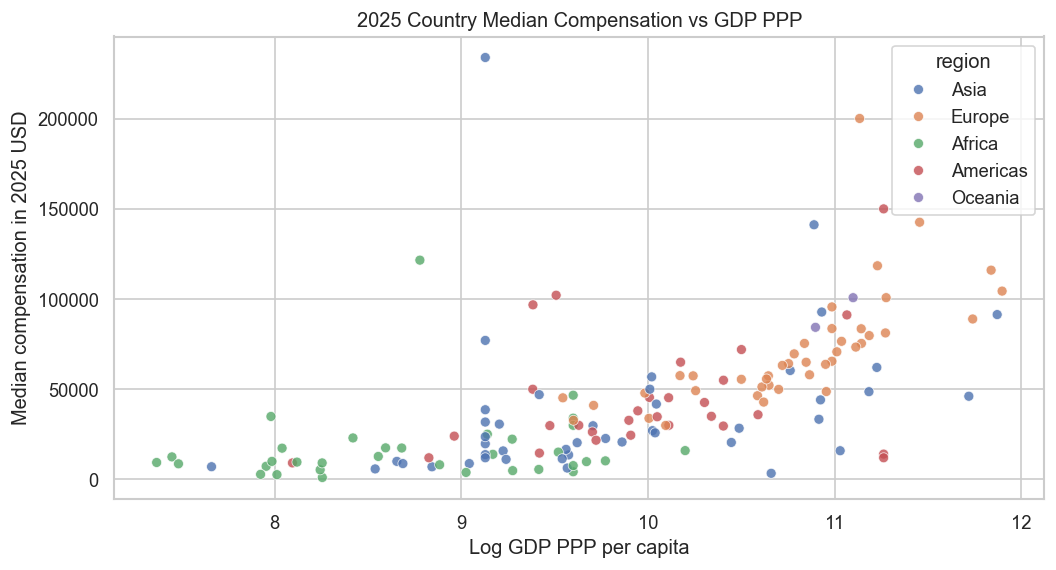

,setup,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
0,Selected main LightGBM,14764.28,17831.0,62955.15,0.57
1,GDP PPP LightGBM,14767.96,17986.1,62963.86,0.57


In [13]:
# Map World Bank API names back to our country names
WORLD_BANK_NAME_MAP = {
    'Russian Federation': 'Russia',
    'Turkiye': 'T?rkiye',
    'Turkey': 'T?rkiye',
    'Egypt, Arab Rep.': 'Egypt',
    'Iran, Islamic Rep.': 'Iran',
    'Korea, Rep.': 'South Korea',
    'Venezuela, RB': 'Venezuela',
    'Czechia': 'Czech Republic',
    'Slovak Republic': 'Slovakia',
    'Hong Kong SAR, China': 'Hong Kong (S.A.R.)',
    'Viet Nam': 'Vietnam'
}

# Fetch the latest GDP PPP per capita data from the World Bank API
url = 'https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.PP.CD?format=json&per_page=400&date=2022'
response = requests.get(url, timeout=30)
response.raise_for_status()
world_bank_payload = response.json()

records = []
for item in world_bank_payload[1]:
    if item['value'] is None:
        continue
    records.append({
        'country_raw': item['country']['value'],
        'gdp_ppp': item['value']
    })

# Remap country names and format clean DataFrame
wb_df = pd.DataFrame(records)
wb_df['country_clean'] = wb_df['country_raw'].replace(WORLD_BANK_NAME_MAP)
wb_df = wb_df[['country_clean', 'gdp_ppp']].drop_duplicates('country_clean')

# Safely merge the GDP PPP data into our core DataFrame
core_macro_df = core_df.merge(wb_df, on='country_clean', how='left')
core_macro_df['gdp_ppp'] = core_macro_df['gdp_ppp'].fillna(core_macro_df.groupby('region')['gdp_ppp'].transform('median'))
core_macro_df['gdp_ppp'] = core_macro_df['gdp_ppp'].fillna(core_macro_df['gdp_ppp'].median())
core_macro_df['log_gdp_ppp'] = np.log(core_macro_df['gdp_ppp'])

print("Merged GDP PPP sample")
display(core_macro_df[['country_clean', 'region', 'gdp_ppp', 'log_gdp_ppp']].sample(5, random_state=RANDOM_STATE))

# Collapse to country-level medians for the test year to visualize the relationship between GDP PPP and compensation in 2025
macro_country_view = (
    core_macro_df.loc[core_macro_df['survey_year'] == TEST_YEAR]
    .groupby(['country_clean', 'region'], as_index=False)
    .agg(
        median_comp_real_2025=(COMP_REAL, 'median'),
        log_gdp_ppp=('log_gdp_ppp', 'median')
    )
)

# Visualize the relationship between GDP PPP and median compensation in 2025 by country, colored by region
plt.figure(figsize=(10, 5))
sns.scatterplot(data=macro_country_view, x='log_gdp_ppp', y='median_comp_real_2025', hue='region', alpha=0.8)
plt.title('2025 Country Median Compensation vs GDP PPP')
plt.xlabel('Log GDP PPP per capita')
plt.ylabel('Median compensation in 2025 USD')
plt.show()

# LightGBM model using the macro-enhanced dataset to see if GDP PPP helps improve predictions
macro_result = fit_window_lightgbm(
    core_macro_df,
    CORE_WINDOW_YEARS,
    VALID_YEAR,
    TEST_YEAR,
    CORE_CAT,
    CORE_NUM + ['log_gdp_ppp'],
    params=NOTEBOOK_TUNED_LGB_PARAMS,
    use_top_tech=True,
    winsor_target=True
)

macro_summary = pd.DataFrame([
    result_row('Selected main LightGBM', selected_main),
    result_row('GDP PPP LightGBM', macro_result)
]).sort_values('valid_medae_real')
display(macro_summary.round(2))

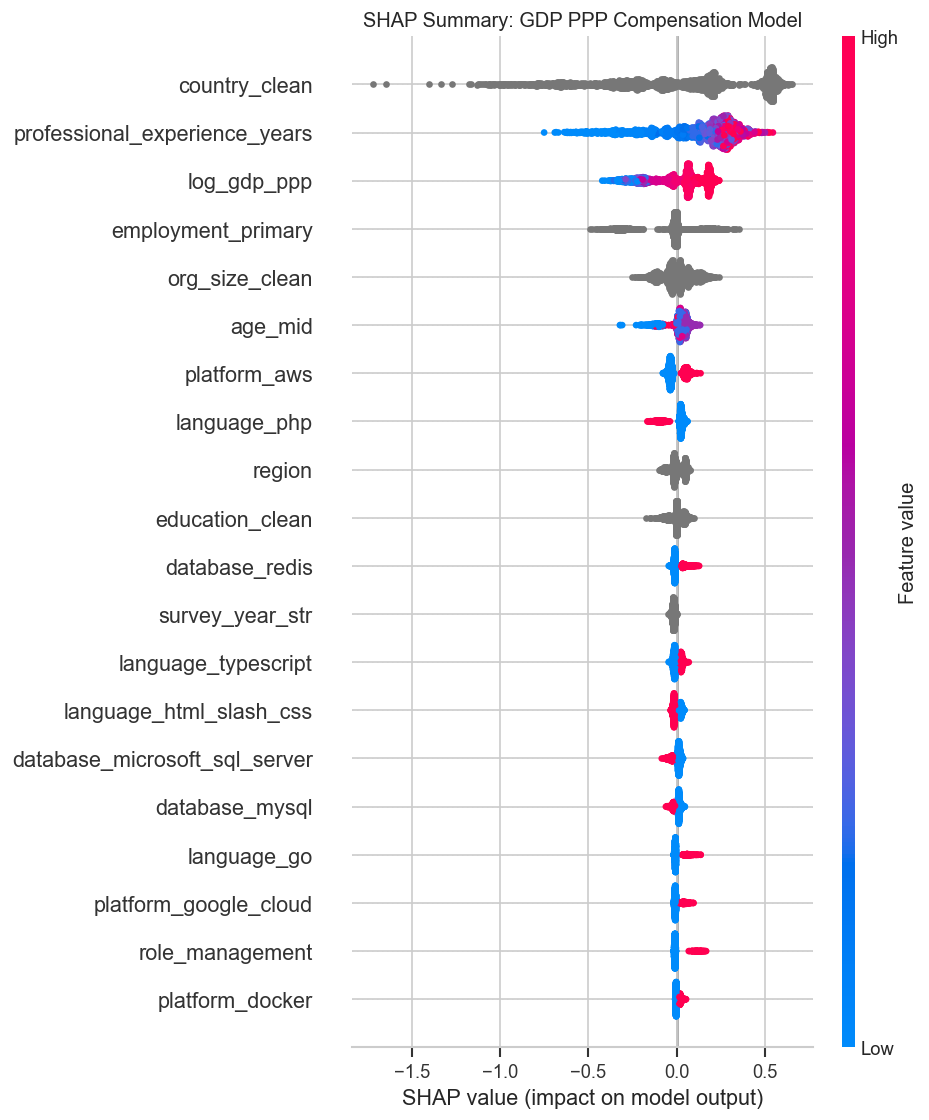

In [14]:
# Show SHAP for the GDP PPP branch so it can be compared to the main model
plot_shap_summary(
    macro_result,
    'SHAP Summary: GDP PPP Compensation Model',
    sample_size=2000,
    max_display=20
)

## Locked Country / Region LightGBM Models

Geography dominates compensation, so it is useful to see what happens once the model is locked inside a specific country or region.

In [15]:
FOCUS_GEOS = [
    ('country', 'United States'),
    ('country', 'India'),
    ('region', 'Europe')
]

geo_models = {}
geo_rows = []

# Fits and evaluates separate LightGBM model for each locked geography
for geo_type, geo_name in FOCUS_GEOS:
    if geo_type == 'country':
        geo_df = core_df.loc[core_df['country_clean'] == geo_name].copy()
        geo_cat = [col for col in CORE_CAT if col not in ['country_clean', 'region']]
    else:
        geo_df = core_df.loc[core_df['region'] == geo_name].copy()
        geo_cat = [col for col in CORE_CAT if col != 'region']

    if geo_df.empty:
        continue

    geo_result = fit_window_lightgbm(
        geo_df,
        CORE_WINDOW_YEARS,
        VALID_YEAR,
        TEST_YEAR,
        geo_cat,
        CORE_NUM,
        params=NOTEBOOK_TUNED_LGB_PARAMS,
        use_top_tech=True,
        winsor_target=True
    )
    geo_models[(geo_type, geo_name)] = geo_result
    geo_rows.append({
        'geo_type': geo_type,
        'geo_name': geo_name,
        'train_rows': len(geo_result['train_df']),
        'valid_rows': len(geo_result['valid_df']),
        'test_rows': len(geo_result['test_df']),
        'valid_medae_real': geo_result['valid_metrics']['medae_real'],
        'test_medae_real': geo_result['test_metrics']['medae_real'],
        'test_rmse_real': geo_result['test_metrics']['rmse_real'],
        'test_r2_log': geo_result['test_metrics']['r2_log']
    })

geo_summary = pd.DataFrame(geo_rows).sort_values('valid_medae_real')
display(geo_summary.round(2))

,geo_type,geo_name,train_rows,valid_rows,test_rows,valid_medae_real,test_medae_real,test_rmse_real,test_r2_log
1,country,India,13470,966,926,6493.33,8367.71,55694.66,0.39
2,region,Europe,89621,10937,10216,12592.10,15325.11,48302.82,0.37
0,country,United States,46123,4232,4372,30815.04,34913.77,93331.36,0.29


Country: United States


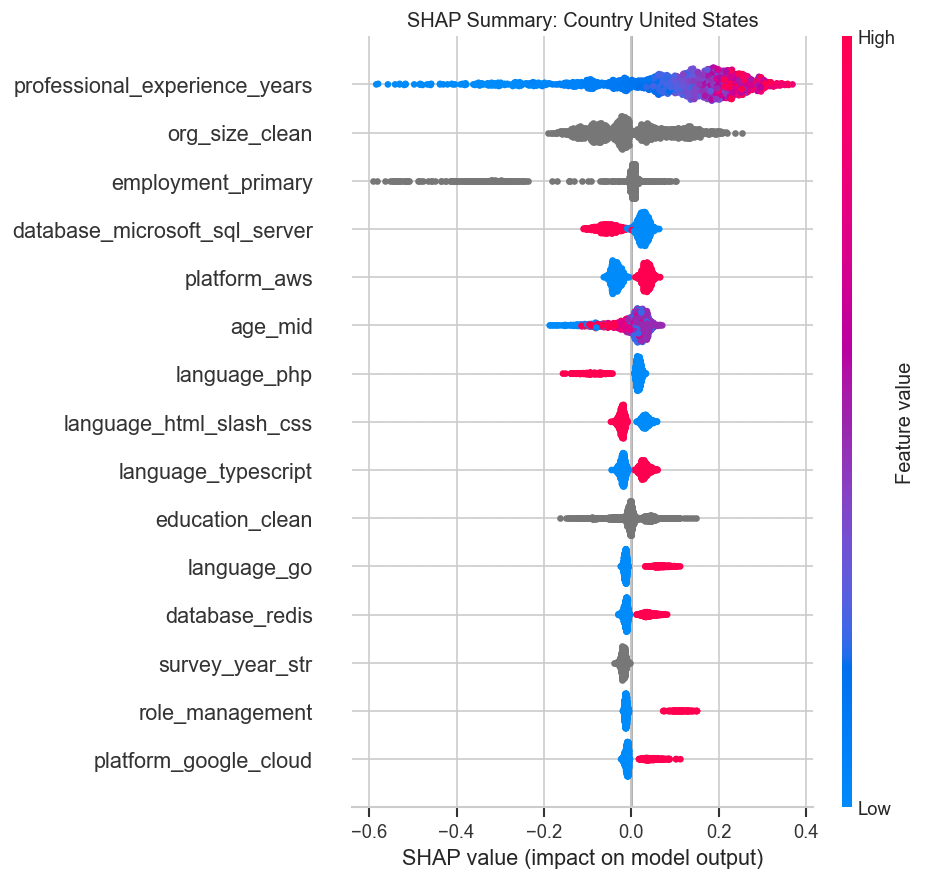

Country: India


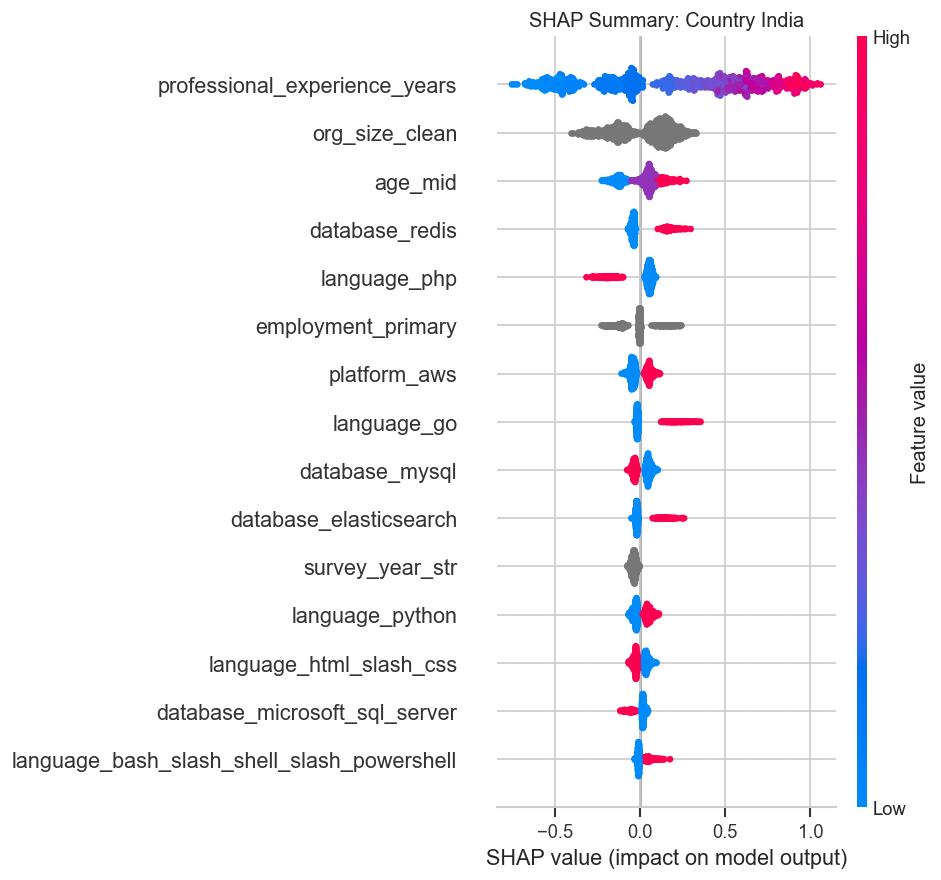

Region: Europe


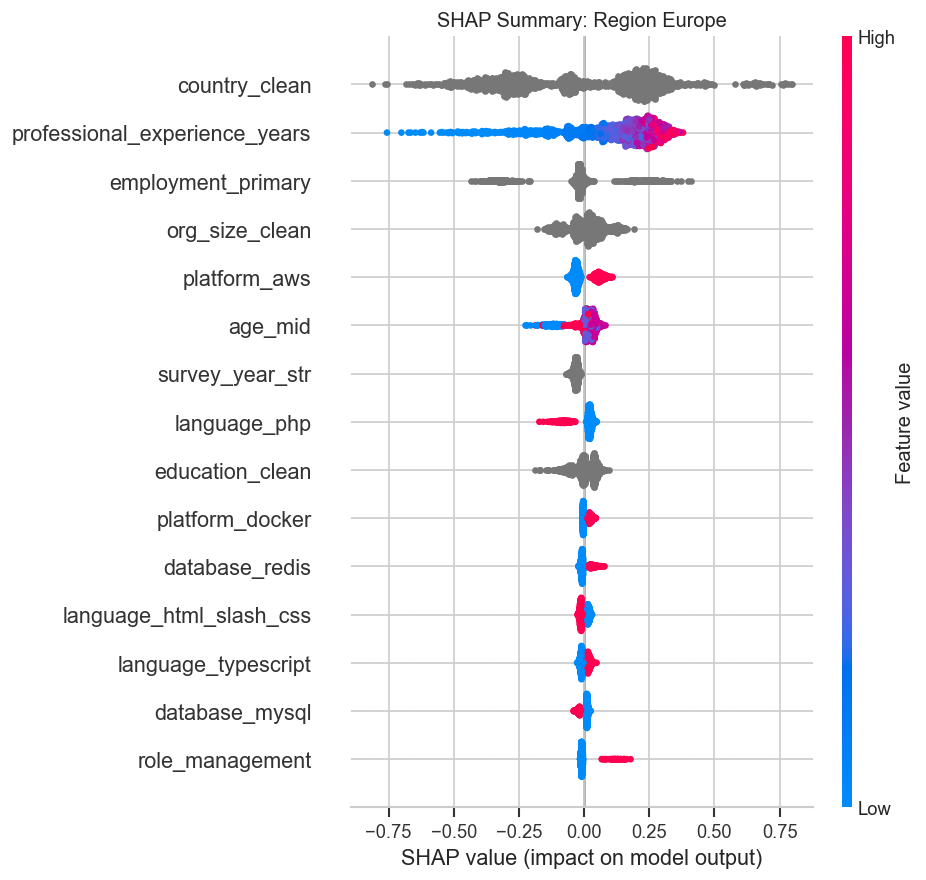

In [16]:
# Show SHAP for each locked geography fit to see what changes once location is fixed
for geo_type, geo_name in FOCUS_GEOS:
    key = (geo_type, geo_name)
    if key not in geo_models:
        continue
    print(f'{geo_type.title()}: {geo_name}')
    plot_shap_summary(
        geo_models[key],
        f'SHAP Summary: {geo_type.title()} {geo_name}',
        sample_size=1500,
        max_display=15
    )

## Rolling-Origin Check

This is the final stability check for the selected model as the training window expands over time.

In [17]:
rolling_rows = []

# Fits LightGBM and Ridge models on multiple rolling origin splits to evaluate stability of performance across different training and validation years
for train_years, valid_year, train_fold, valid_fold in rolling_origin_splits(core_df, min_train_year=2019, final_valid_year=2024):
    ridge_fold = fit_ridge_holdout(train_fold, valid_fold, valid_fold, CORE_CAT, CORE_NUM, alphas=[25.0])
    plain_fold = fit_window_lightgbm(
        pd.concat([train_fold, valid_fold], axis=0),
        train_years,
        valid_year,
        valid_year,
        CORE_CAT,
        CORE_NUM,
        params=NOTEBOOK_TUNED_LGB_PARAMS,
        use_top_tech=True,
        winsor_target=False
    )
    winsor_fold = fit_window_lightgbm(
        pd.concat([train_fold, valid_fold], axis=0),
        train_years,
        valid_year,
        valid_year,
        CORE_CAT,
        CORE_NUM,
        params=NOTEBOOK_TUNED_LGB_PARAMS,
        use_top_tech=True,
        winsor_target=True
    )

    rolling_rows.extend([
        {
            'setup': 'Ridge core alpha=25.0',
            'train_years': ','.join(map(str, train_years)),
            'valid_year': valid_year,
            **ridge_fold['valid_metrics']
        },
        {
            'setup': 'LightGBM core + top tech flags [tuned]',
            'train_years': ','.join(map(str, train_years)),
            'valid_year': valid_year,
            **plain_fold['valid_metrics']
        },
        {
            'setup': 'LightGBM winsorized target + top tech flags [tuned]',
            'train_years': ','.join(map(str, train_years)),
            'valid_year': valid_year,
            **winsor_fold['valid_metrics']
        }
    ])

rolling_df = pd.DataFrame(rolling_rows)
rolling_summary = (
    rolling_df
    .groupby('setup', as_index=False)
    .agg(
        fold_count=('valid_year', 'size'),
        mean_valid_medae_real=('medae_real', 'mean'),
        mean_valid_rmse_real=('rmse_real', 'mean'),
        mean_valid_r2_log=('r2_log', 'mean')
    )
    .sort_values('mean_valid_medae_real')
)

display(rolling_summary.round(2))

,setup,fold_count,mean_valid_medae_real,mean_valid_rmse_real,mean_valid_r2_log
1,LightGBM winsorized target + top tech flags [t...,5,14408.38,97619.91,0.64
0,LightGBM core + top tech flags [tuned],5,14448.53,97574.10,0.64
2,Ridge core alpha=25.0,5,19934.78,102678.23,0.54


## Next Steps

- keep the tuned LightGBM family as the main compensation benchmark
- keep the GDP PPP, locked-geography, and two-stage branches as side analyses unless they clearly beat the simpler main model
- revisit feature additions only if they improve the core window without giving up too much training history

## Feature Importance Ranking & Prediction Error by Country

Close with the top feature importances from the selected LightGBM fit and the countries where the 2025 holdout errors are still largest.

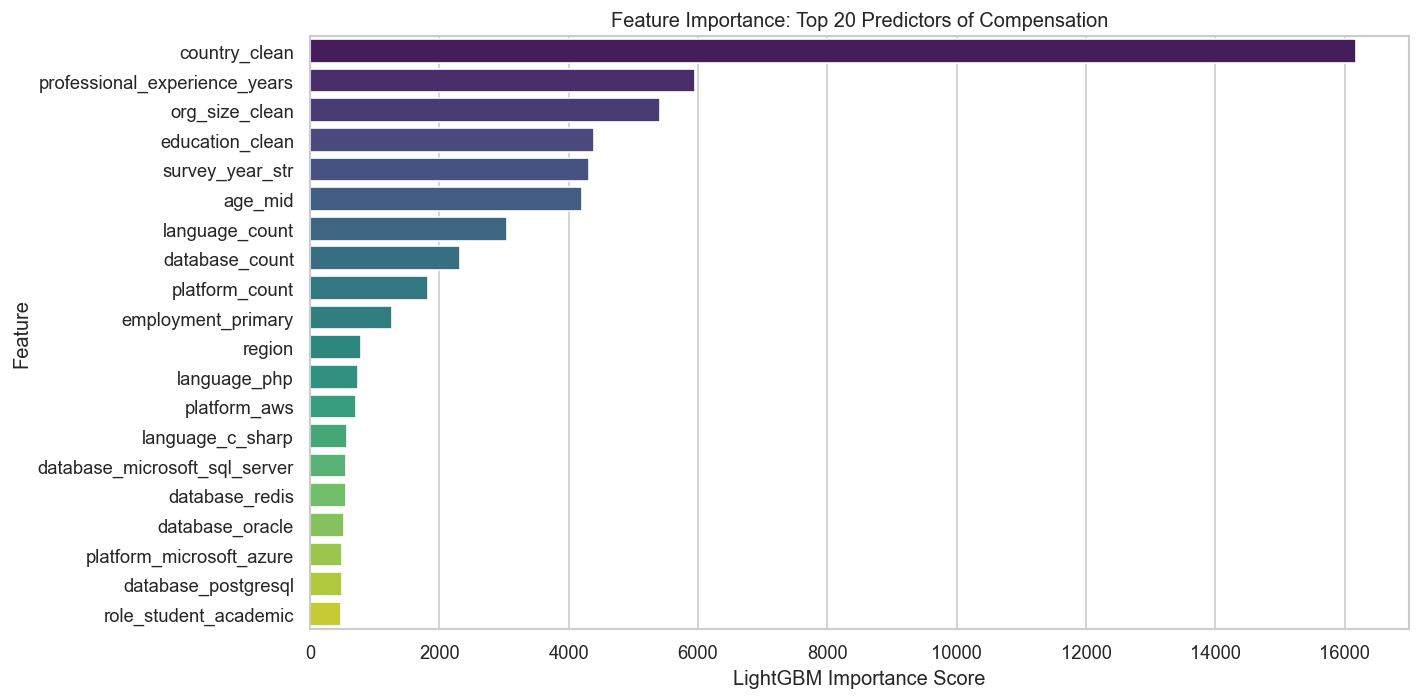

Top 20 Feature Importances


,feature,importance
2,country_clean,16180
7,professional_experience_years,5954
5,org_size_clean,5418
4,education_clean,4389
0,survey_year_str,4314
6,age_mid,4207
8,language_count,3044
9,database_count,2321
10,platform_count,1826
3,employment_primary,1275


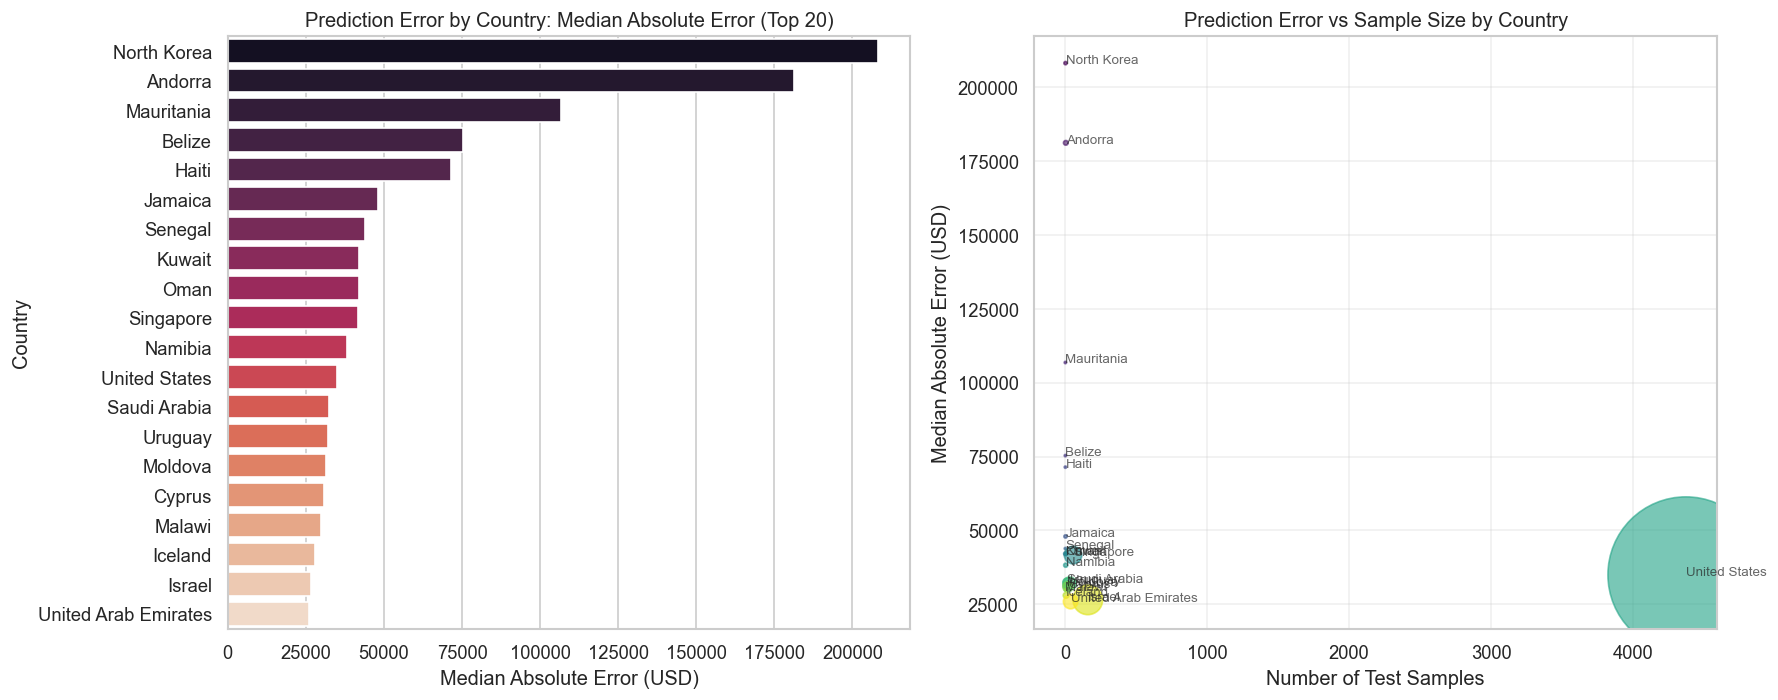

Prediction Error by Country (Top 20 by Error)


,country_clean,count,median_abs_error,mean_abs_error,rmse,median_pct_error
100,North Korea,2,208109.69,208109.69,293319.38,49.67
3,Andorra,4,181139.08,158533.73,175726.00,74.30
85,Mauritania,1,106815.98,106815.98,106815.98,87.86
15,Belize,1,75327.87,75327.87,75327.87,73.76
52,Haiti,1,71418.28,71418.28,71418.28,780.61
65,Jamaica,2,47977.73,47977.73,54694.71,45.71
116,Senegal,1,43884.83,43884.83,43884.83,190.82
71,Kuwait,3,42132.43,36987.42,41434.45,170.45
103,Oman,1,42016.19,42016.19,42016.19,1242.71
118,Singapore,55,41666.61,62237.19,109638.43,34.73


In [18]:
selected_model = selected_main['model']
feature_importance_df = pd.DataFrame({
    'feature': selected_main['feature_cols'],
    'importance': selected_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance: Top 20 Predictors of Compensation')
plt.xlabel('LightGBM Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Top 20 Feature Importances')
display(feature_importance_df.round(4))


# Prediction Error by Country
# Calculate prediction errors for the test set by country
test_results = selected_main['test_df'].copy()
test_results['pred_log'] = selected_main['test_pred']
test_results['pred_real'] = np.exp(selected_main['test_pred'])
test_results['actual_real'] = np.exp(test_results[COMP_TARGET])
test_results['abs_error'] = np.abs(test_results['actual_real'] - test_results['pred_real'])
test_results['pct_error'] = np.abs(test_results['actual_real'] - test_results['pred_real']) / test_results['actual_real'] * 100

# Group by country and calculate error metrics
country_error_df = (
    test_results
    .groupby('country_clean', as_index=False)
    .agg(
        count=('abs_error', 'size'),
        median_abs_error=('abs_error', 'median'),
        mean_abs_error=('abs_error', 'mean'),
        rmse=('abs_error', lambda x: np.sqrt(np.mean(x**2))),
        median_pct_error=('pct_error', 'median')
    )
    .sort_values('median_abs_error', ascending=False)
    .head(20)  # Top 20 countries with highest errors
)

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: Median absolute error by country
sns.barplot(data=country_error_df, x='median_abs_error', y='country_clean', ax=axes[0], palette='rocket')
axes[0].set_title('Prediction Error by Country: Median Absolute Error (Top 20)')
axes[0].set_xlabel('Median Absolute Error (USD)')
axes[0].set_ylabel('Country')

# Right plot: Sample size and error together
ax2 = axes[1]
ax2.scatter(
    country_error_df['count'],
    country_error_df['median_abs_error'],
    s=country_error_df['count'] * 2,
    alpha=0.6,
    c=range(len(country_error_df)),
    cmap='viridis'
)
for _, row in country_error_df.iterrows():
    ax2.annotate(
        row['country_clean'],
        (row['count'], row['median_abs_error']),
        fontsize=8,
        alpha=0.7
    )
ax2.set_xlabel('Number of Test Samples')
ax2.set_ylabel('Median Absolute Error (USD)')
ax2.set_title('Prediction Error vs Sample Size by Country')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Prediction Error by Country (Top 20 by Error)')
display(country_error_df.round(2))